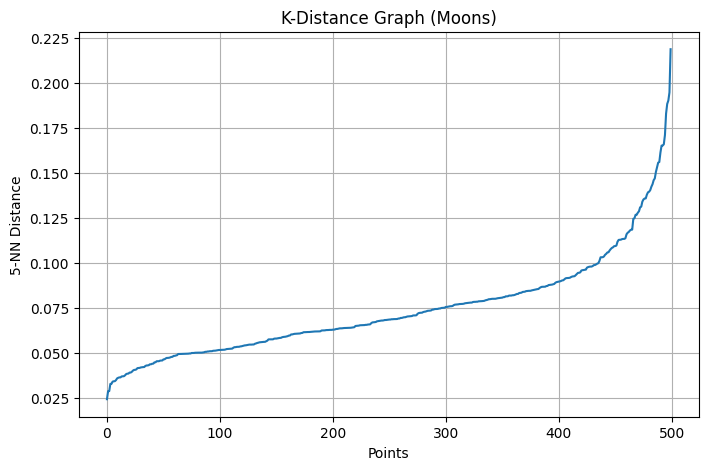

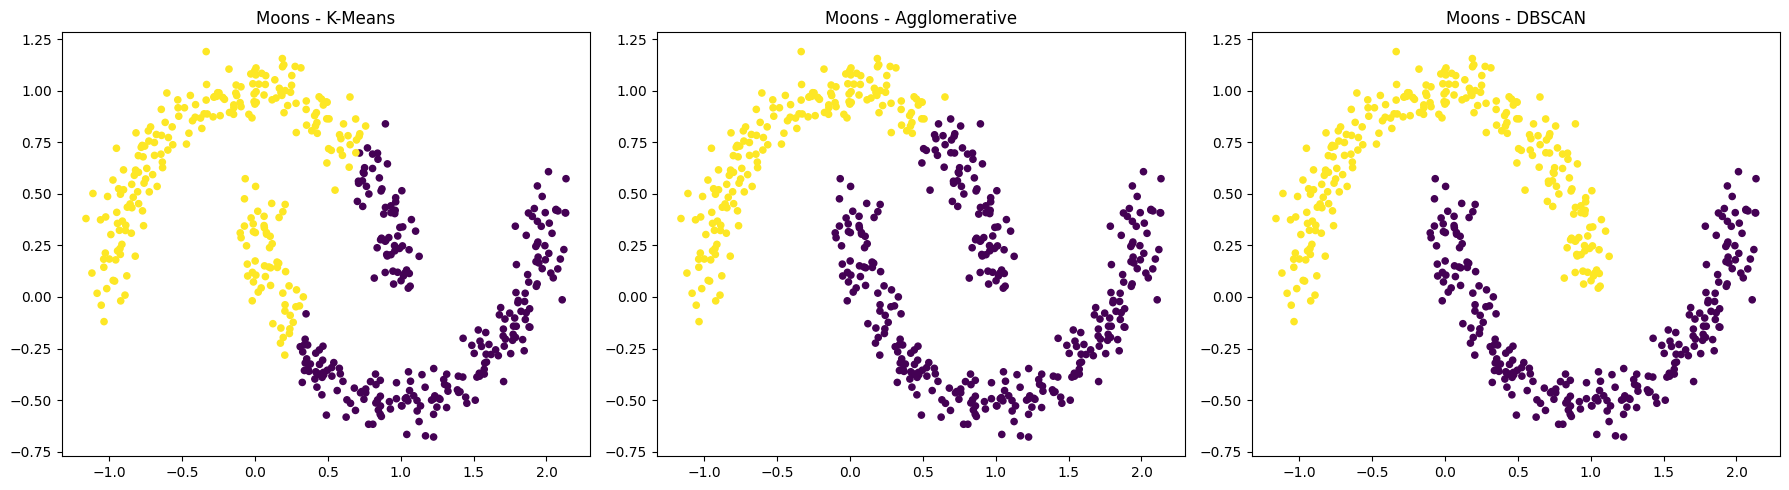

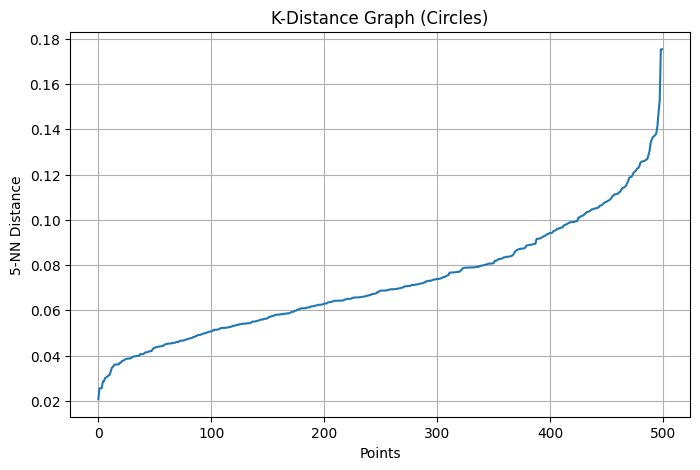

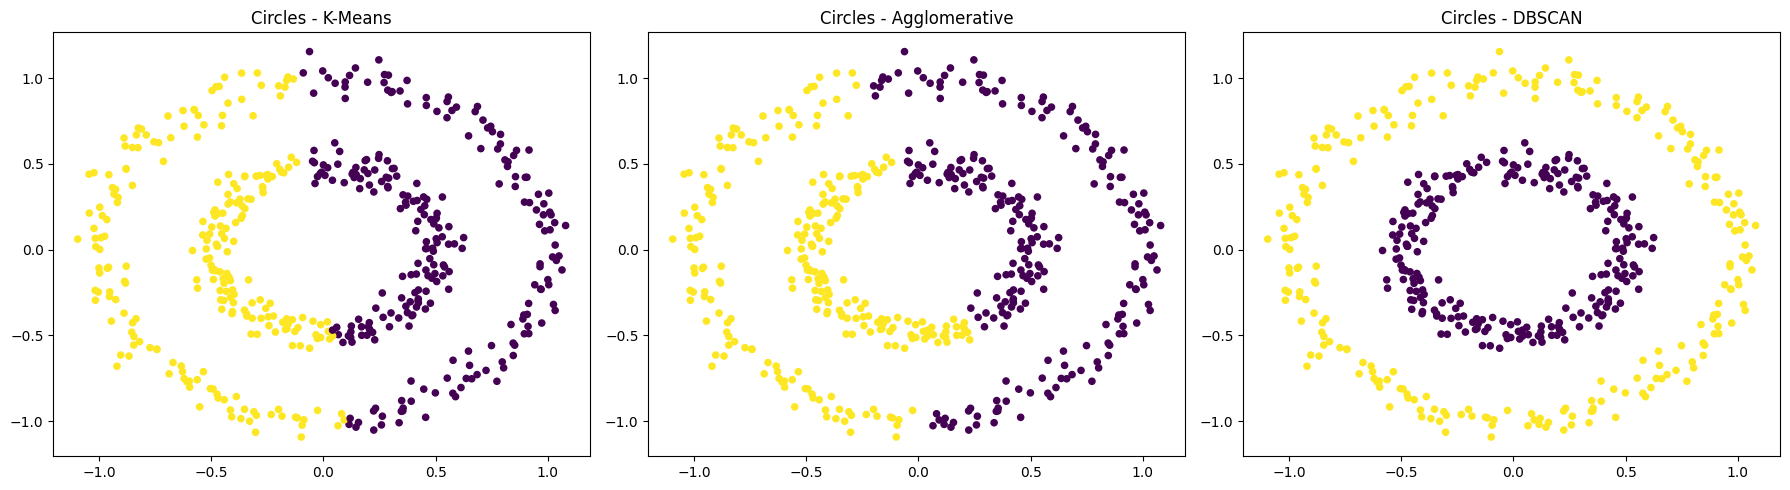



COMPARISON TABLE
   Dataset      Algorithm  Silhouette Score
0    Moons        K-Means          0.485759
1    Moons  Agglomerative          0.444352
2    Moons         DBSCAN          0.330576
3  Circles        K-Means          0.353594
4  Circles  Agglomerative          0.346242
5  Circles         DBSCAN          0.112593


SUMMARY TABLE
Algorithm  Agglomerative    DBSCAN   K-Means
Dataset                                     
Circles         0.346242  0.112593  0.353594
Moons           0.444352  0.330576  0.485759


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.datasets import make_circles

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score

from sklearn.neighbors import NearestNeighbors

moons_X, _ = make_moons(
    n_samples=500,
    noise=0.08,
    random_state=42
)

circles_X, _ = make_circles(
    n_samples=500,
    noise=0.05,
    factor=0.5,
    random_state=42
)

datasets = {
    "Moons": moons_X,
    "Circles": circles_X
}

results = []

for dataset_name, X in datasets.items():

    neighbors = NearestNeighbors(
        n_neighbors=5
    )

    neighbors.fit(X)

    distances, indices = neighbors.kneighbors(X)

    distances = np.sort(
        distances[:, 4]
    )

    plt.figure(figsize=(8,5))

    plt.plot(distances)

    plt.title(
        f"K-Distance Graph ({dataset_name})"
    )

    plt.xlabel("Points")

    plt.ylabel("5-NN Distance")

    plt.grid(True)

    plt.show()

    kmeans = KMeans(
        n_clusters=2,
        random_state=42,
        n_init=10
    )

    kmeans_labels = kmeans.fit_predict(X)

    agg = AgglomerativeClustering(
        n_clusters=2
    )

    agg_labels = agg.fit_predict(X)

    dbscan = DBSCAN(
        eps=0.20,
        min_samples=5
    )

    dbscan_labels = dbscan.fit_predict(X)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18,5)
    )

    algorithms = [
        ("K-Means", kmeans_labels),
        ("Agglomerative", agg_labels),
        ("DBSCAN", dbscan_labels)
    ]

    for ax, (name, labels) in zip(
        axes,
        algorithms
    ):

        ax.scatter(
            X[:,0],
            X[:,1],
            c=labels,
            cmap="viridis",
            s=20
        )

        ax.set_title(
            f"{dataset_name} - {name}"
        )

    plt.tight_layout()

    plt.show()

    if len(np.unique(kmeans_labels)) > 1:

        score = silhouette_score(
            X,
            kmeans_labels
        )

        results.append([
            dataset_name,
            "K-Means",
            score
        ])

    if len(np.unique(agg_labels)) > 1:

        score = silhouette_score(
            X,
            agg_labels
        )

        results.append([
            dataset_name,
            "Agglomerative",
            score
        ])

    unique_dbscan = set(
        dbscan_labels
    )

    if len(unique_dbscan) > 1:

        valid_points = dbscan_labels != -1

        if len(
            np.unique(
                dbscan_labels[valid_points]
            )
        ) > 1:

            score = silhouette_score(
                X[valid_points],
                dbscan_labels[valid_points]
            )

            results.append([
                dataset_name,
                "DBSCAN",
                score
            ])

comparison_df = pd.DataFrame(
    results,
    columns=[
        "Dataset",
        "Algorithm",
        "Silhouette Score"
    ]
)

print("\n")
print("="*60)
print("COMPARISON TABLE")
print("="*60)

print(comparison_df)

pivot_df = comparison_df.pivot(
    index="Dataset",
    columns="Algorithm",
    values="Silhouette Score"
)

print("\n")
print("="*60)
print("SUMMARY TABLE")
print("="*60)

print(pivot_df)

In [24]:
import joblib

dbscan_model = DBSCAN(
    eps=0.20,
    min_samples=5
)

dbscan_model.fit(moons_X)

joblib.dump(
    dbscan_model,
    "dbscan_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [25]:
from google.colab import files

files.download(
    "dbscan_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>